```text
┌─────────────────────────────────────────────────────────────────────────────┐
│                                                                             │
│   BEFORE (last week):                                                       │
│                                                                             │
│   "Is there a relationship between X and Y?"                                │
│                                                                             │
│   → stats.linregress  → slope, p-value, r²                                 │
│                                                                             │
│                                                                             │
│   AFTER (today):                                                            │
│                                                                             │
│   "Given a NEW person, will they get diabetes?"                             │
│                                                                             │
│   → model.fit()  → model.predict()  → Yes / No                             │
│                                                                             │
│                                                                             │
│   Same data.  Same math underneath.  New SUPERPOWER.                        │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
```

In [3]:
# ==============================================
# RUN THIS CELL FIRST - All imports for today
# ==============================================

# Libraries you already know
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats      # We'll use linregress one more time

# Display settings
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded (all familiar from Weeks 3-4)!")

print(f"  NumPy   : {np.__version__}")
print(f"  Pandas  : {pd.__version__}")
print(f"  Seaborn : {sns.__version__}")
print(f"  SciPy   : stats.linregress ready")

print()
print("No new libraries yet - we'll introduce scikit-learn step by step.")

Libraries loaded (all familiar from Weeks 3-4)!
  NumPy   : 2.4.6
  Pandas  : 3.0.3
  Seaborn : 0.13.2
  SciPy   : stats.linregress ready

No new libraries yet - we'll introduce scikit-learn step by step.


# Part 1: Quick Recap — Linear Regression

## Where We Left Off Last Week

---


> ### Reminder: `stats.linregress` from Last Week
>
> Last week you used **SciPy** to find the **line of best fit**:
>
> ```python
> slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
> ```
>
> Let's see it one more time — with a picture.

In [4]:
# Temperature vs Ice Cream Sales - our data
temperature = np.array([15, 18, 20, 22, 25, 27, 30, 32, 35])
sales       = np.array([42, 53, 60, 72, 85, 92, 108, 115, 130])

df_ice = pd.DataFrame({'Temperature': temperature, 'Sales': sales})
print("Our data:")
display(df_ice.T)

Our data:


,0,1,2,3,4,5,6,7,8
Temperature,15,18,20,22,25,27,30,32,35
Sales,42,53,60,72,85,92,108,115,130


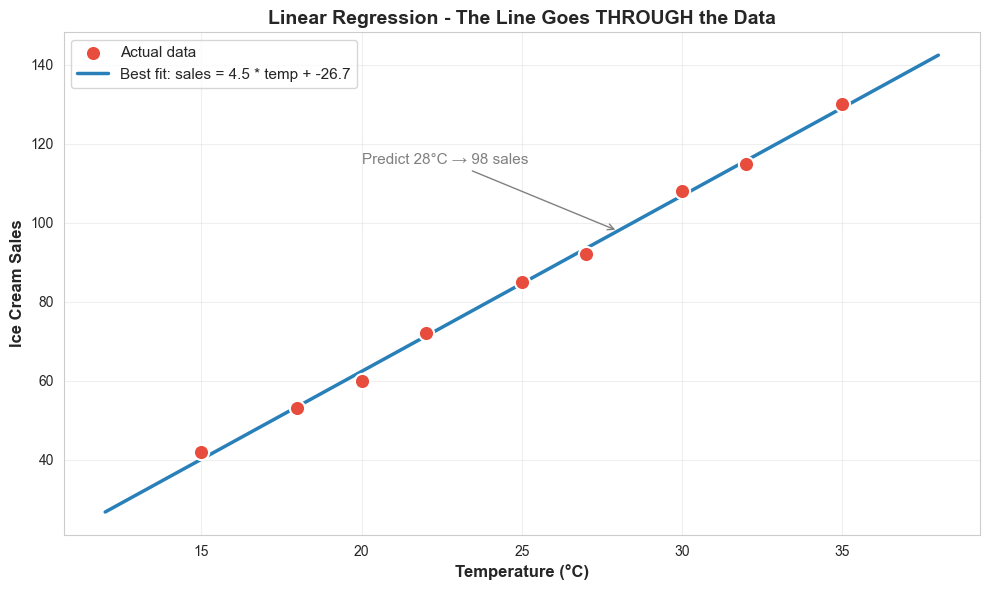

stats.linregress results:
 slope     = 4.45 (for each +1°C, sales ↑ by ~4)
 intercept = -26.66
 r-value   = 0.999 (strong positive correlation)
 p-value = 0.000000 (statistically significant)

Prediction for 28°C: 4.45 * 28 + -26.66 = 98 sales

→ The output is always a NUMBER.


In [5]:
# Week 4 approach: stats.linregress + visual
slope, intercept, r_value, p_value, std_err = stats.linregress(temperature, sales)

fig, ax = plt.subplots(figsize=(10, 6))

# Data points
ax.scatter(temperature, sales, s=120, color='#e74c3c', zorder=5,
           edgecolors='white', linewidth=1.5, label='Actual data')

# Regression line
x_line = np.linspace(12, 38, 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color='#2980b9', linewidth=2.5,
        label=f'Best fit: sales = {slope:.1f} * temp + {intercept:.1f}')

# Annotate a prediction
ax.annotate(f'Predict 28°C → {slope*28 + intercept:.0f} sales',
            xy=(28, slope*28 + intercept), xytext=(20, 115),
            arrowprops=dict(arrowstyle='->', color='grey'),
            fontsize=11, color='grey')

ax.set_xlabel('Temperature (°C)', fontsize=12, fontweight='bold')
ax.set_ylabel('Ice Cream Sales', fontsize=12, fontweight='bold')
ax.set_title('Linear Regression - The Line Goes THROUGH the Data',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("stats.linregress results:")
print(f" slope     = {slope:.2f} (for each +1°C, sales ↑ by ~{slope:.0f})")
print(f" intercept = {intercept:.2f}")
print(f" r-value   = {r_value:.3f} (strong positive correlation)")
print(f" p-value = {p_value:.6f} (statistically significant)")
print(f"\nPrediction for 28°C: {slope:.2f} * 28 + {intercept:.2f} = {slope*28 + intercept:.0f} sales")
print("\n→ The output is always a NUMBER.")

# Regression vs Classification — Side by Side

```text
REGRESSION (what you know):           CLASSIFICATION (what's next):

Output = a NUMBER                     Output = a CATEGORY


Sales                                 Diabetic?

130 |               •                 YES |   •  •     • •
100 |          •                       |   •  •  • •
 70 |     •   /                        |══════════════════ decision line
 40 | •   /                         NO | • •   •
    |                                  | • • • • •
    └───────────────               └──────────────────
      15   25   35 °C                low       high
                                      glucose level


Line goes THROUGH the data.         Line goes BETWEEN the groups.

"How many ice creams?"              "Diabetes: yes or no?"

→ answer: 97.3                      → answer: YES
```

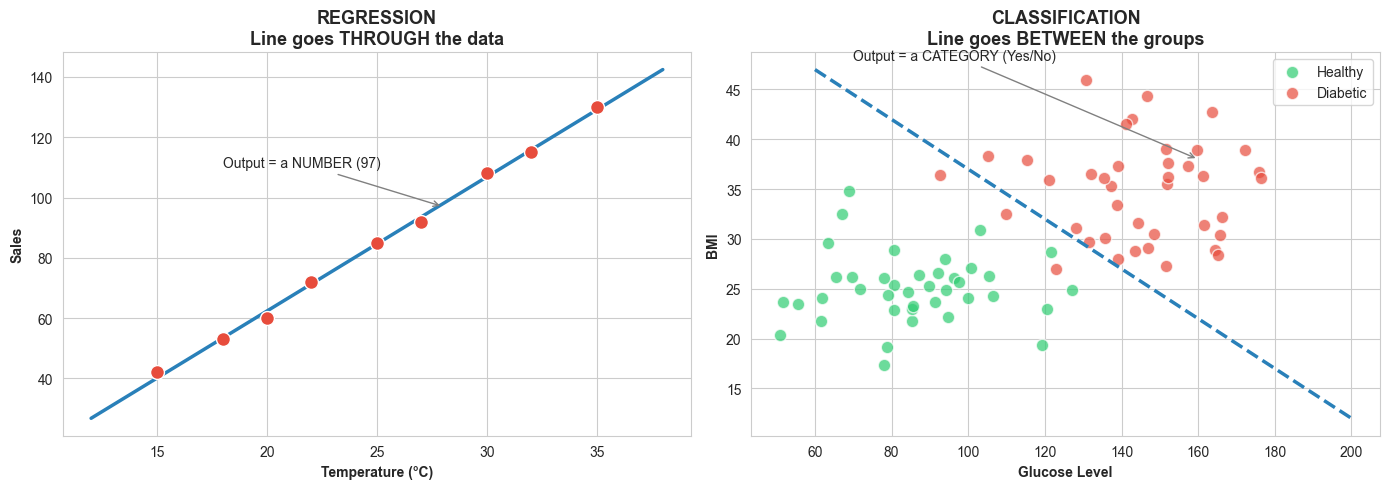

LEFT:  Regression → output is a NUMBER  (how many sales?)
RIGHT: Classification → output is a CATEGORY (healthy or diabetic?)

Both draw a line. The PURPOSE of the line is different.


In [6]:
# Let's SEE both side by side with real charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LEFT: Regression (what you know)
ax1 = axes[0]
ax1.scatter(temperature, sales, s=100, color='#e74c3c', zorder=5, edgecolors='white')
ax1.plot(x_line, y_line, color='#2980b9', linewidth=2.5)
ax1.set_xlabel('Temperature (°C)', fontweight='bold')
ax1.set_ylabel('Sales', fontweight='bold')
ax1.set_title('REGRESSION\nLine goes THROUGH the data', fontweight='bold', fontsize=13)
ax1.annotate('Output = a NUMBER (97)', xy=(28, 97), fontsize=10, 
             xytext=(18, 110), arrowprops=dict(arrowstyle='->', color='grey'))

# RIGHT: Classification (what's next)
np.random.seed(42)
n_each = 40
glucose_healthy = np.random.normal(90, 20, n_each)
glucose_diabetic = np.random.normal(145, 20, n_each)
bmi_healthy = np.random.normal(25, 4, n_each)
bmi_diabetic = np.random.normal(35, 5, n_each)

ax2 = axes[1]
ax2.scatter(glucose_healthy, bmi_healthy, s=80, color='#2ecc71',
            label='Healthy', alpha=0.7, edgecolors='white')
ax2.scatter(glucose_diabetic, bmi_diabetic, s=80, color='#e74c3c',
            label='Diabetic', alpha=0.7, edgecolors='white')

# Draw a rough decision boundary
x_boundary = np.linspace(60, 200, 100)
# This linear equation creates the boundary line seen in the plot
y_boundary = -0.25 * x_boundary + 62 
ax2.plot(x_boundary, y_boundary, color='#2980b9', linestyle='--', linewidth=2.5)

ax2.set_xlabel('Glucose Level', fontweight='bold')
ax2.set_ylabel('BMI', fontweight='bold')
ax2.set_title('CLASSIFICATION\nLine goes BETWEEN the groups', fontweight='bold', fontsize=13)
ax2.legend()

ax2.annotate('Output = a CATEGORY (Yes/No)', xy=(160, 38), fontsize=10,
             xytext=(70, 48), arrowprops=dict(arrowstyle='->', color='grey'))

plt.tight_layout()
plt.show()

print("LEFT:  Regression → output is a NUMBER  (how many sales?)")
print("RIGHT: Classification → output is a CATEGORY (healthy or diabetic?)")
print("\nBoth draw a line. The PURPOSE of the line is different.")

```text
────────────────────────────────────────────────────────────────────────────

Part 2: From Lines to Categories — What is Classification?

How Logistic Regression Works

────────────────────────────────────────────────────────────────────────────
```

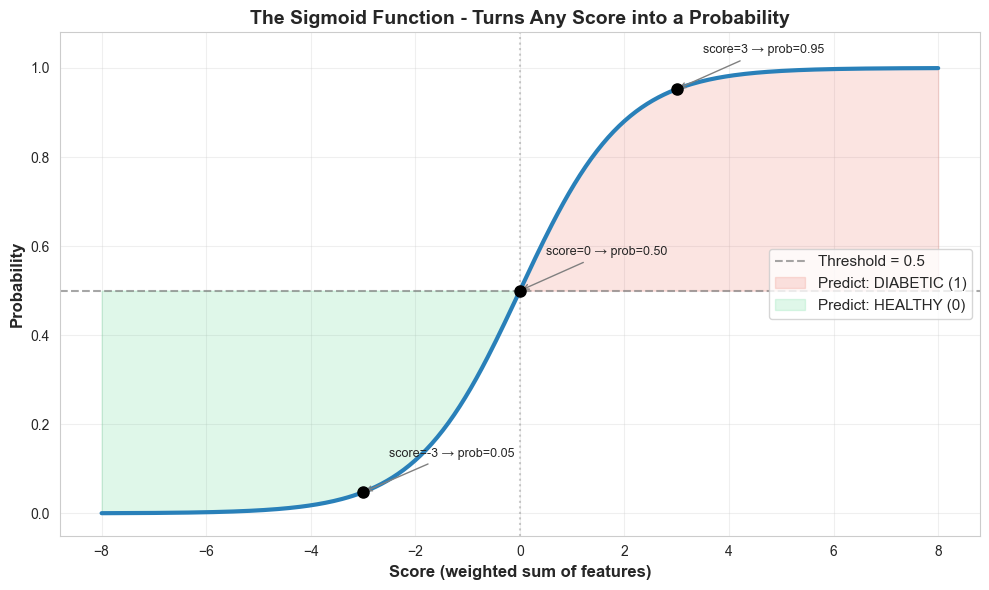

How it works:
 1. Compute: score = w1×glucose + w2×BMI + w3×age + ...
 2. Sigmoid: probability = sigmoid(score)
 3. Decide: probability > 0.5 → DIABETIC, else → HEALTHY


In [7]:
# The sigmoid function - the heart of logistic regression

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-8, 8, 300)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(z, sigmoid(z), color='#2980b9', linewidth=3)
ax.axhline(0.5, color='grey', linestyle='--', alpha=0.7, label='Threshold = 0.5')
ax.axvline(0, color='grey', linestyle=':', alpha=0.4)

# Shade the regions
ax.fill_between(z, sigmoid(z), 0.5, where=(sigmoid(z) > 0.5),
                alpha=0.15, color='#e74c3c', label='Predict: DIABETIC (1)')
ax.fill_between(z, sigmoid(z), 0.5, where=(sigmoid(z) <= 0.5),
                alpha=0.15, color='#2ecc71', label='Predict: HEALTHY (0)')

# Annotate specific points
for score, label in [(3, 'score=3 → prob=0.95'), (-3, 'score=-3 → prob=0.05'),
                     (0, 'score=0 → prob=0.50')]:
    prob = sigmoid(score)
    ax.plot(score, prob, 'ko', markersize=8, zorder=5)
    ax.annotate(label, xy=(score, prob), xytext=(score + 0.5, prob + 0.08),
                fontsize=9, arrowprops=dict(arrowstyle='->', color='grey'))

ax.set_xlabel('Score (weighted sum of features)', fontsize=12, fontweight='bold')
ax.set_ylabel('Probability', fontsize=12, fontweight='bold')
ax.set_title('The Sigmoid Function - Turns Any Score into a Probability',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='center right')
ax.set_ylim(-0.05, 1.08)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("How it works:")
print(" 1. Compute: score = w1×glucose + w2×BMI + w3×age + ...")
print(" 2. Sigmoid: probability = sigmoid(score)")
print(" 3. Decide: probability > 0.5 → DIABETIC, else → HEALTHY")

# Logistic Regression — How It Actually Works

### Step 1: Compute a Score *(just like linear regression)*

```text
score = w₁ × glucose + w₂ × BMI + w₃ × age + ... + bias
```

### Step 2: Push Through the Sigmoid Function

→ Converts the score into a **probability between 0 and 1**

### Step 3: Apply a Threshold

- Probability **> 0.5** → **Diabetic**
- Probability **≤ 0.5** → **Healthy**

In [8]:
# End-to-end example with made-up weights

# Imagine the model has learned these weights:
weights = {'Glucose': 0.04, 'BMI': 0.03, 'Age': 0.02}
bias = -6.0

# Two patients:
patients = pd.DataFrame({
    'Name': ['Patient A', 'Patient B'],
    'Glucose': [85, 170],
    'BMI': [24, 38],
    'Age': [25, 55],
})

print("TWO PATIENTS:")
display(patients)

print("\nStep-by-step prediction:")
print("=" * 65)
for _, p in patients.iterrows():
    score = (weights['Glucose'] * p['Glucose'] + 
             weights['BMI'] * p['BMI'] + 
             weights['Age'] * p['Age'] + bias)
    prob = sigmoid(score)
    prediction = "DIABETIC" if prob > 0.5 else "HEALTHY"
    
    print(f"\n {p['Name']} (Glucose={p['Glucose']}, BMI={p['BMI']}, Age={p['Age']})")
    print(f"  Step 1 - Score: {weights['Glucose']:.2f} * {p['Glucose']} + "
          f"{weights['BMI']:.2f} * {p['BMI']} + {weights['Age']:.2f} * {p['Age']} "
          f"+ ({bias}) = {score:.2f}")
    print(f"  Step 2 - Sigmoid: sigmoid({score:.2f}) = {prob:.4f}")
    print(f"  Step 3 - Decision: {prob:.4f} {' > ' if prob > 0.5 else ' <= '} 0.5 → {prediction}")

TWO PATIENTS:


,Name,Glucose,BMI,Age
0,Patient A,85,24,25
1,Patient B,170,38,55



Step-by-step prediction:

 Patient A (Glucose=85, BMI=24, Age=25)
  Step 1 - Score: 0.04 * 85 + 0.03 * 24 + 0.02 * 25 + (-6.0) = -1.38
  Step 2 - Sigmoid: sigmoid(-1.38) = 0.2010
  Step 3 - Decision: 0.2010  <=  0.5 → HEALTHY

 Patient B (Glucose=170, BMI=38, Age=55)
  Step 1 - Score: 0.04 * 170 + 0.03 * 38 + 0.02 * 55 + (-6.0) = 3.04
  Step 2 - Sigmoid: sigmoid(3.04) = 0.9543
  Step 3 - Decision: 0.9543  >  0.5 → DIABETIC


# Part 3: Meet scikit-learn — Your New Toolbox

## Four Concepts You Need Before We Code

---

## What is scikit-learn?

**scikit-learn** (imported as `sklearn`) is Python's standard machine learning library.

### YOUR PYTHON DATA SCIENCE STACK:

```text
┌──────────────────────────────────────────────────────────────┐
│  scikit-learn (sklearn)  - Machine Learning        NEW!      │
├──────────────────────────────────────────────────────────────┤
│  SciPy (scipy.stats)    - Statistics             Week 4      │
├──────────────────────────────────────────────────────────────┤
│  NumPy (np)             - Fast arrays            Week 4      │
├──────────────────────────────────────────────────────────────┤
│  Pandas (pd)            - DataFrames             Week 3      │
└──────────────────────────────────────────────────────────────┘
```

**Each layer is BUILT on the ones below.**

`sklearn` works seamlessly with pandas DataFrames and NumPy arrays.

# Why We Split Data: Train vs Test

```text
THE EXAM ANALOGY:

    BAD approach (no split):

        Study with 100 questions + answers
                    ↓
        Exam uses THE SAME 100 questions
                    ↓
        Score: 100% ... but you MEMORISED, not LEARNED.



    GOOD approach (train/test split):

        Study with 80 questions + answers      ← TRAINING SET
                    ↓
        Exam uses 20 NEW questions             ← TEST SET
                    ↓
        Score: 82% — REAL performance on unseen questions!
```

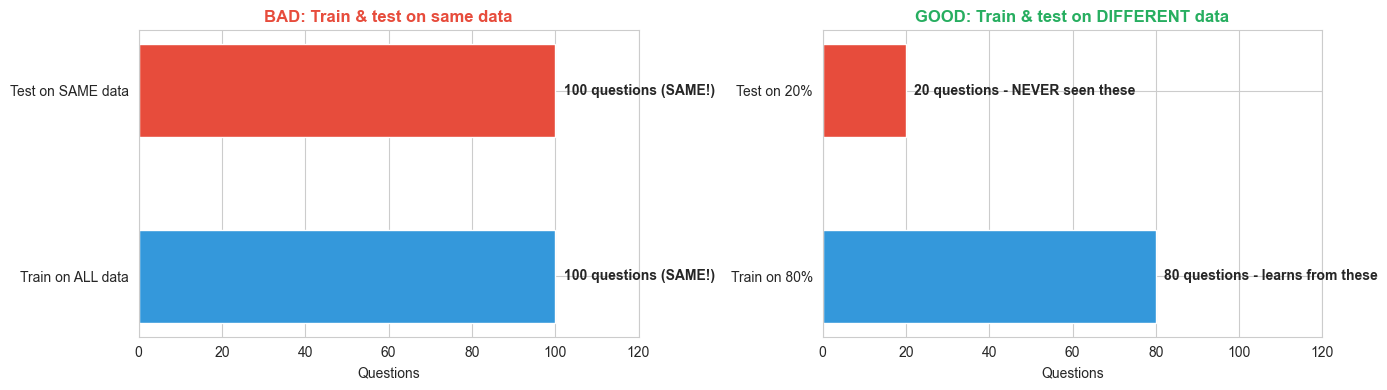

The Golden Rule: NEVER let the model see the test data during training.
That's like giving students the exam answers beforehand.


In [9]:
# Let's visualize the split concept

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# BAD: no split
ax1 = axes[0]
ax1.barh(['Train on ALL data', 'Test on SAME data'], [100, 100],
         color=['#3498db', '#e74c3c'], height=0.5)
ax1.set_xlim(0, 120)
ax1.set_title('BAD: Train & test on same data', fontweight='bold', fontsize=12,
              color='#e74c3c')
ax1.set_xlabel('Questions')
for i, v in enumerate([100, 100]):
    ax1.text(v + 2, i, f'{v} questions (SAME!)', va='center', fontweight='bold')

# GOOD: split
ax2 = axes[1]
ax2.barh(['Train on 80%', 'Test on 20%'], [80, 20],
         color=['#3498db', '#e74c3c'], height=0.5)
ax2.set_xlim(0, 120)
ax2.set_title('GOOD: Train & test on DIFFERENT data', fontweight='bold', fontsize=12,
              color='#27ae60')
ax2.set_xlabel('Questions')
for i, v in enumerate([80, 20]):
    label = 'learns from these' if v == 80 else 'NEVER seen these'
    ax2.text(v + 2, i, f'{v} questions - {label}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("The Golden Rule: NEVER let the model see the test data during training.")
print("That's like giving students the exam answers beforehand.")

In [10]:
# === LIVE CODING: train_test_split in action ===
# from sklearn.model_selection import train_test_split
#
# 1. Create a small dataset: 10 students, hours studied, pass/fail
# 2. Use train_test_split(X, y, test_size=0.2, random_state=42)
# 3. Print training set and test set - how many in each?

from sklearn.model_selection import train_test_split

study_hours = pd.DataFrame({
    'Hours': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
})
passed = pd.Series([0, 0, 0, 0, 1, 1, 1, 1, 1, 1], name="Passed") # 0 = fail, 1 = pass

print(f" Hours: {study_hours['Hours'].tolist()}")
print(f" Passed: {passed.tolist()}")

# Split!
# features = X
# labels/target = y
X_train, X_test, y_train, y_test = train_test_split(study_hours,
                                                    passed,
                                                    test_size=0.2,
                                                    random_state=42)

print(f"\nTRAINING SET ({len(X_train)} students - model LEARNS from these):")
print(f" Hours: {X_train['Hours'].tolist()}")
print(f" Passed: {y_train.tolist()}")
print()

print(f"\nTEST SET ({len(y_test)} students - model is TESTED on these):")
print(f" Hours: {X_test['Hours'].tolist()}")
print(f" Passed: {y_test.tolist()}")

 Hours: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
 Passed: [0, 0, 0, 0, 1, 1, 1, 1, 1, 1]

TRAINING SET (8 students - model LEARNS from these):
 Hours: [7, 2, 9, 4, 11, 6, 5, 8]
 Passed: [1, 0, 1, 0, 1, 1, 0, 1]


TEST SET (2 students - model is TESTED on these):
 Hours: [10, 3]
 Passed: [1, 0]


```text
WHAT train_test_split DOES:

    Your full dataset (e.g., 768 patients)

    ┌───────────────────────────────────────────────────────┐
    │ patient 1, patient 2, patient 3, ... patient 768     │
    └───────────────────────────────────────────────────────┘

                     ↓ shuffle randomly + split

    ┌───────────────────────────────────┐   ┌───────────────┐
    │        TRAINING SET (80%)         │   │   TEST SET    │
    │                                   │   │               │
    │ ~614 patients                     │   │ ~154          │
    │ model LEARNS from these           │   │ patients      │
    │                                   │   │ model is      │
    │                                   │   │ TESTED on     │
    │                                   │   │ these         │
    └───────────────────────────────────┘   └───────────────┘


    You get FOUR variables:

    X_train  =  features of training patients
    X_test   =  features of test patients

    y_train  =  answers for training patients   (model CAN see these)
    y_test   =  answers for test patients       (model CANNOT peek!)
```

In [11]:
# Let's SEE why standardisation matters

# Load a preview of the diabetes data to show the scale problem
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
           'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
diabetes_preview = pd.read_csv(url, names=columns)

print("FEATURE RANGES (look how different they are!):")
print("=" * 55)
for col in columns[:-1]: # skip Outcome
    mn, mx = diabetes_preview[col].min(), diabetes_preview[col].max()
    bar = '|' * int((mx - mn) / 20)
    print(f"{col:30s} {mn:6.0f} - {mx:6.0f} {bar}")

print("\n→ Insulin ranges 0–846. Pregnancies ranges 0–17.")
print("  Without scaling, the model thinks Insulin is ~50x more important!")

FEATURE RANGES (look how different they are!):
Pregnancies                         0 -     17 
Glucose                             0 -    199 |||||||||
BloodPressure                       0 -    122 ||||||
SkinThickness                       0 -     99 ||||
Insulin                             0 -    846 ||||||||||||||||||||||||||||||||||||||||||
BMI                                 0 -     67 |||
DiabetesPedigreeFunction            0 -      2 
Age                                21 -     81 |||

→ Insulin ranges 0–846. Pregnancies ranges 0–17.
  Without scaling, the model thinks Insulin is ~50x more important!


In [12]:
# === LIVE CODING: Scaling the data ===
# from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler
# 1. Take a small sample (as before)
X_sample = diabetes_preview[['Glucose', 'BMI', 'Age', 'Pregnancies']].head(5)
print("BEFORE scaling:")
display(X_sample)

# 2. Create and fit the scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)

# 3. Convert back to DataFrame for readability
X_scaled_df = pd.DataFrame(X_scaled, columns=X_sample.columns)
print("\nAFTER scaling:")
display(X_scaled_df)

print("\nWhat changed?")
print("→ All features are now centered around 0 with a standard deviation of 1.")
print("→ The model now sees 'Insulin' and 'Pregnancies' as equally important.")

BEFORE scaling:


,Glucose,BMI,Age,Pregnancies
0,148,33.6,50,6
1,85,26.6,31,1
2,183,23.3,32,8
3,89,28.1,21,1
4,137,43.1,33,0



AFTER scaling:


,Glucose,BMI,Age,Pregnancies
0,0.528565,0.383768,1.775223,0.878438
1,-1.170394,-0.626149,-0.256659,-0.690201
2,1.472431,-1.102252,-0.149718,1.505894
3,-1.062524,-0.409738,-1.326070,-0.690201
4,0.231921,1.754370,-0.042776,-1.003929



What changed?
→ All features are now centered around 0 with a standard deviation of 1.
→ The model now sees 'Insulin' and 'Pregnancies' as equally important.


# StandardScaler — How To Use It

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Step 1: fit_transform on TRAINING data  (learn the scale, then apply)
X_train_scaled = scaler.fit_transform(X_train)

# Step 2: transform ONLY on TEST data  (use the SAME scale from training)
X_test_scaled = scaler.transform(X_test)

```text
CRITICAL RULE:

    ┌─────────────────────────────────────────────────────────────┐
    │  fit_transform(X_train)   →  learn mean & std from train   │
    │  transform(X_test)        →  use SAME mean & std           │
    │                                                           │
    │  NEVER fit on test data! That's DATA LEAKAGE.            │
    └─────────────────────────────────────────────────────────────┘
```

## The sklearn Pattern — Three Lines of ML

In [14]:
# === LIVE CODING: Finalizing the Logistic Regression Model ===
# from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegression
# 1. Create a model: model = LogisticRegression()
# 2. Train it: model.fit(X_train_scaled, y_train)
# 3. Predict: predictions = model.predict(X_test_scaled)
# 4. Check accuracy: print(model.score(X_test_scaled, y_test))

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Look at the weights the model learned!
print("Learned weights (coefficients):")
for feature, weight in zip(X_train.columns, model.coef_[0]):
    print(f" {feature:12s}: {weight:.4f}")
print(f" Bias: {model.intercept_[0]:.4f}")

Learned weights (coefficients):
 Hours       : 1.2643
 Bias: 0.6832


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

# Get predictions from the test set
predictions = model.predict(X_test_scaled)

# 1. Accuracy: Overall percentage of correct predictions
print(f"Accuracy:  {accuracy_score(y_test, predictions):.2%}")

# 2. Precision: Out of all predicted positives, how many were actually positive?
print(f"Precision: {precision_score(y_test, predictions):.2%}")

# 3. Recall: Out of all actual positives, how many did we correctly find?
print(f"Recall:    {recall_score(y_test, predictions):.2%}")

# 4. Confusion Matrix: A grid showing True Positives, True Negatives, 
#    False Positives, and False Negatives.
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

Accuracy:  100.00%
Precision: 100.00%
Recall:    100.00%

Confusion Matrix:
[[1 0]
 [0 1]]


# Comparison: Week 4 vs Week 5

|                      | **SciPy (Week 4)** | **scikit-learn (Week 5)** |
|----------------------|--------------------|---------------------------|
| **Code** | `slope, intercept, r, p, err = stats.linregress(x, y)` | `model = LogisticRegression()` |
| | *(one function call, returns numbers)* | `model.fit(X_train, y_train)` |
| | `predicted = slope * new_x + intercept` *(manual)* | `model.predict(X_new)` *(automatic)* |
| **Output** | **Numbers** (slope, p-value, r²) | **A model object** that can predict forever |
| **Purpose** | *"What's the relationship?"* | *"Predict for NEW data"* |

---

### Key Difference

**Week 4 (SciPy):**
- Focused on statistics and relationships.
- Returned values such as slope, intercept, correlation, and p-values.
- Predictions were calculated manually.

**Week 5 (scikit-learn):**
- Focused on machine learning and prediction.
- Trains a reusable model object.
- Predictions are generated automatically using `.predict()`.

> **SciPy helps you understand data.**  
> **scikit-learn helps you make predictions from data.**

In [16]:
# Using X_tr, y_tr, X_te from the split we did earlier:
# 1. CREATE: demo_model = LogisticRegression(random_state=42)
# 2. FIT:    demo_model.fit(__, __)
# 3. PREDICT: demo_pred = demo_model.predict(__)
#
# Then print and compare predictions vs actual (y_te)

from sklearn.linear_model import LogisticRegression

print("TRAINIG DATA: ")
print(f"  Hours: {study_hours['Hours'].tolist()}")
print(f"  Passed: {passed.tolist()}")
print()

# Three lines!
model = LogisticRegression() # 1. CREATE
model.fit(X_train, y_train)  # 2. FIT (learn)
prediction = model.predict(X_test) # 3. PREDICT (new data)

print("Test data (model has NEVER seen these):")
print(f"  Hours studied: {X_test['Hours'].tolist()}")
print(f"  Predicted: {prediction.tolist()}")
print(f"  Actual: {y_test.tolist()}")
print()

TRAINIG DATA: 
  Hours: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
  Passed: [0, 0, 0, 0, 1, 1, 1, 1, 1, 1]

Test data (model has NEVER seen these):
  Hours studied: [10, 3]
  Predicted: [1, 0]
  Actual: [1, 0]



```text
What we've covered so far:

✓ Recap: linear regression visualised — the line goes THROUGH the data

✓ Classification: the line goes BETWEEN the groups

✓ The sigmoid: turns any score into a probability (0–1)

✓ Logistic regression: score → sigmoid → threshold → YES/NO

✓ scikit-learn: the new ML library in your stack

✓ Train/test split: hide 20% so the model can't cheat

✓ StandardScaler: put all features on the same playing field

✓ The three-line pattern: CREATE → FIT → PREDICT


Coming up:

    → Load a REAL medical dataset (Exercise 1)

    → Build your first classifier (Exercises 2–3)

    → Measure how good it is (Exercise 4)
```

---

# Part 4: The Diabetes Problem

## Exercises 1–3: Load, Prepare, Train

---

## Practice: Exercise 1 — Understanding the Problem & Data Collection (8 minutes)

**We want to predict if an individual will have diabetes.**

1. **Load** the dataset using the code below

2. **Explore** it:
   - `.head()`
   - `.info()`
   - `.describe()`

3. **How many positive and negative cases are there?**
   - Use `.value_counts()` on the **Outcome** column

4. **Split** the data into:
   - Training set (**80%**)
   - Testing set (**20%**)

---

### Goal

By the end of this exercise, you should be able to:

- Understand the structure of the dataset
- Identify the target variable (`Outcome`)
- Check class balance (positive vs negative cases)
- Create training and testing datasets for machine learning

In [17]:
# Load the dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
           'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
diabetes = pd.read_csv(url, names=columns)

In [18]:
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [19]:
diabetes.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [20]:
diabetes.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [21]:
diabetes.isna().sum()  # Check for missing values (there are none, but some zeros are actually missing data)

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [22]:
# 3. Positive / negative cases
print("TARGET DISTRIBUTION")
counts = diabetes['Outcome'].value_counts()
print(f"Negative(healthy):  {counts[0]} ({counts[0]/len(diabetes) * 100:.1f}%)")
print(f"Positive(diabetic): {counts[1]} ({counts[1]/len(diabetes) * 100:.1f}%)")

TARGET DISTRIBUTION
Negative(healthy):  500 (65.1%)
Positive(diabetic): 268 (34.9%)


### Reminders:

- `Outcome` is the target column (**1 = diabetic, 0 = healthy**)

- Use:

  ```python
  from sklearn.model_selection import train_test_split
  ```

- Split the data with:

  ```python
  train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
  ```

- `X = diabetes.drop('Outcome', axis=1)`
  
  → all columns **EXCEPT** the answer

- `y = diabetes['Outcome']`
  
  → just the answer

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

X = diabetes.drop('Outcome', axis=1)  # Features
y = diabetes['Outcome']               # Target variable

# Split the data into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {len(X_train)} patients {(len(X_train)/len(diabetes) * 100):.1f}% of data")
print(f"Test set size: {len(X_test)} patients {(len(X_test)/len(diabetes) * 100):.1f}% of data")
print(f"Training diabetes rate: {y_train.mean() * 100:.1f}%")
print(f"Test diabetes rate: {y_test.mean() * 100:.1f}%")

# Standardize the features (important for logistic regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Binary classification with logistic regression
model = LogisticRegression(random_state=42, max_iter=1000) #class_weight="balanced" max_iter=1000 to ensure convergence
model.fit(X_train_scaled, y_train)
predictions = model.predict(X_test_scaled)


# compare first 10 predictions with actual values in a nice table
comparison = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': predictions[:10],
    'Match': ['✓' if a == p else 'x' for a, p in zip(y_test.values[:10], predictions[:10])]
})


print("\nFirst 10 predictions vs actual:")
display(comparison)

# Overall accuracy
correct = (predictions == y_test.values).sum()
total = len(y_test)

print(f"\nOverall: {correct} correct out of {total} ({correct/total*100:.1f}%)")

print("\nEvaluation Metrics:")
print(f"Accuracy:  {accuracy_score(y_test, predictions):.2%}")
print(f"Precision: {precision_score(y_test, predictions):.2%}")
print(f"Recall:    {recall_score(y_test, predictions):.2%}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))


Training set size: 614 patients 79.9% of data
Test set size: 154 patients 20.1% of data
Training diabetes rate: 34.7%
Test diabetes rate: 35.7%

First 10 predictions vs actual:


,Actual,Predicted,Match
0,0,0,✓
1,0,0,✓
2,0,0,✓
3,0,0,✓
4,0,0,✓
5,0,0,✓
6,0,0,✓
7,0,1,x
8,0,1,x
9,0,1,x



Overall: 116 correct out of 154 (75.3%)

Evaluation Metrics:
Accuracy:  75.32%
Precision: 64.91%
Recall:    67.27%

Confusion Matrix:
[[79 20]
 [18 37]]


```text
MODEL SELECTION
===============================================================

We choose Logistic Regression because:
  - Binary classification problem (diabetes: yes / no)
  - Standard first-choice baseline for binary classification
  - Fast, interpretable, outputs probabilities
```

In [29]:
# To USE a different threshold — bypass .predict (uses 0.5 by default)

y_probabilities = model.predict_proba(X_test_scaled)[:, 1]  # Raw probabilities
print(y_probabilities[:10])
y_pred_with_threshold = (y_probabilities >= 0.3).astype(int)
print(y_pred_with_threshold[:10])

[0.27736383 0.18595977 0.11465752 0.17139617 0.46843793 0.43994646
 0.01619214 0.65955117 0.5361637  0.77058281]
[0 0 0 0 1 1 0 1 1 1]


---

# Part 5: How Good Is Our Model? — Evaluation Metrics

## Going Beyond "It Looks About Right"

---


## The Confusion Matrix

```text
                         PREDICTED
                 Healthy (0)   Diabetic (1)
               ┌─────────────┬─────────────┐
ACTUAL Healthy │     TN      │     FP      │
(0)            │ (Correct!)  │ (False Alarm)│
               ├─────────────┼─────────────┤
ACTUAL Diabetic│     FN      │     TP      │
(1)            │ (MISSED!!)  │ (Correct!) │
               └─────────────┴─────────────┘


TN = True Negative   - Said healthy, IS healthy        ✓
TP = True Positive   - Said diabetic, IS diabetic      ✓
FP = False Positive  - Said diabetic, IS healthy       (false alarm)
FN = False Negative  - Said healthy, IS DIABETIC       (MISSED – dangerous!)
```

### Memory trick:

- **First word** = Were we right? *(True ✓ / False ✗)*
- **Second word** = What did we predict? *(Positive / Negative)*

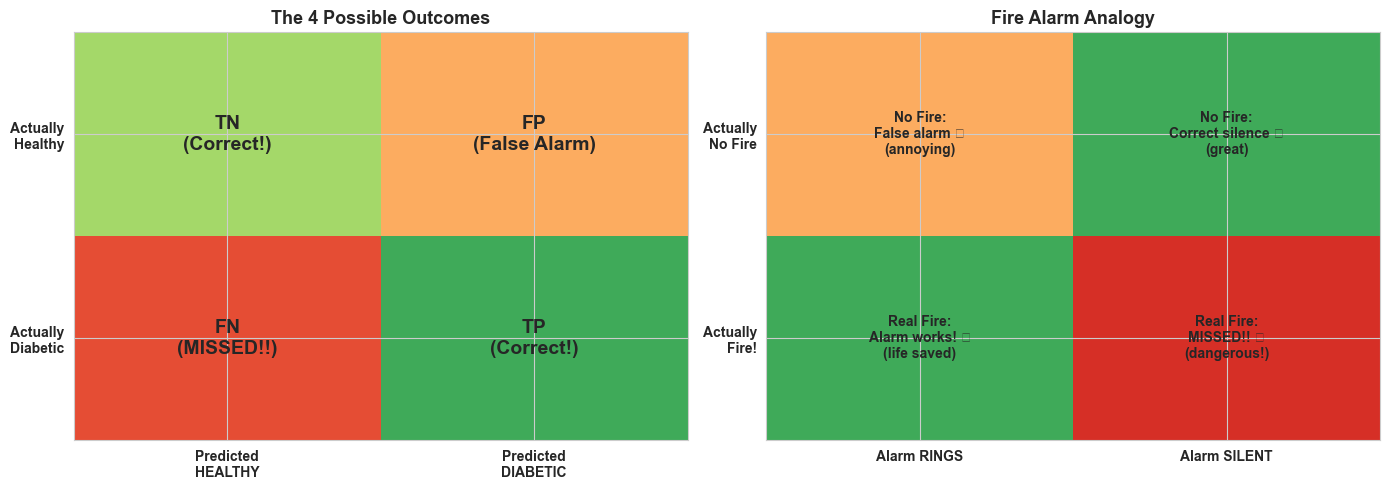

In [25]:
# The fire alarm analogy — visualised

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix as a concept
labels = np.array([['TN\n(Correct!)', 'FP\n(False Alarm)'],
                   ['FN\n(MISSED!!)', 'TP\n(Correct!)']])
colors = np.array([[0.7, 0.3], [0.15, 0.85]])

ax1 = axes[0]
ax1.imshow(colors, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
for i in range(2):
    for j in range(2):
        ax1.text(j, i, labels[i, j], ha='center', va='center',
                 fontsize=14, fontweight='bold')
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Predicted\nHEALTHY', 'Predicted\nDIABETIC'], fontweight='bold')
ax1.set_yticks([0, 1])
ax1.set_yticklabels(['Actually\nHealthy', 'Actually\nDiabetic'], fontweight='bold')
ax1.set_title('The 4 Possible Outcomes', fontweight='bold', fontsize=13)

# The fire alarm analogy
scenarios = ['Fire Alarm\nGoes Off', 'Fire Alarm\nStays Silent']
outcomes_fire = ['No Fire\n(False Alarm)\n→ Annoying', 'No Fire\n(Correct!)\n→ Great']
outcomes_miss = ['Real Fire\n(Correct!)\n→ Life saved', 'Real Fire\n(MISSED!!)\n→ Danger!']

ax2 = axes[1]
table_data = [['No Fire:\nFalse alarm 🔔\n(annoying)', 'No Fire:\nCorrect silence ✓\n(great)'],
              ['Real Fire:\nAlarm works! ✓\n(life saved)', 'Real Fire:\nMISSED!! 🔥\n(dangerous!)']]
colors2 = np.array([[0.3, 0.85], [0.85, 0.1]])
ax2.imshow(colors2, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
for i in range(2):
    for j in range(2):
        ax2.text(j, i, table_data[i][j], ha='center', va='center',
                 fontsize=10, fontweight='bold')
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Alarm RINGS', 'Alarm SILENT'], fontweight='bold')
ax2.set_yticks([0, 1])
ax2.set_yticklabels(['Actually\nNo Fire', 'Actually\nFire!'], fontweight='bold')
ax2.set_title('Fire Alarm Analogy', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

## The Four Metrics — From the Confusion Matrix

| Metric | Question | Formula | Fire Alarm Version |
|----------|----------|----------|----------|
| **Accuracy** | What % overall correct? | `(TP + TN) / Total` | "How often is the alarm right?" |
| **Precision** | When we say positive, are we right? | `TP / (TP + FP)` | "When the alarm rings, is there really a fire?" |
| **Recall** | Did we catch all positives? | `TP / (TP + FN)` | "If there's a fire, does the alarm ring?" |
| **F1 Score** | Balance of precision & recall | `2 × (P × R) / (P + R)` | "Overall judgement" |

> **Key idea:**  
> All four metrics come directly from the values in the confusion matrix (**TP, TN, FP, FN**).

```text
THE ACCURACY TRAP:


    Dataset: 950 healthy + 50 diabetic = 1000 patients


    Stupid model: ALWAYS says "healthy"
        Accuracy = 950 / 1000 = 95%    ← WOW!
        Recall   = 0 / 50    = 0%      ← caught ZERO diabetics. USELESS.


    Lesson: Accuracy alone can be MISLEADING.
            Always check precision AND recall.
```

## Practice: Exercise 4 — Evaluation Metrics (10 minutes)

Using the predictions from Exercise 3 (`y_pred`), compute and visualise:

1. **Accuracy score** — comment on the result
2. **Confusion matrix** — plot it and interpret: what mistakes does the model make?
3. **Precision, Recall, F1** — comment on what they tell you

### Import:

```python
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)
```

### Hints:

- All metrics take `(y_test, y_pred)`
- `ConfusionMatrixDisplay.from_predictions(y_test, y_pred)` for a nice plot
- `classification_report(y_test, y_pred)` for everything in one call

In [26]:
# Your code here – Exercise 4
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report,
                             precision_score, recall_score, f1_score)

print(classification_report(y_test, predictions, target_names=['Healthy', 'Diabetic']))

              precision    recall  f1-score   support

     Healthy       0.81      0.80      0.81        99
    Diabetic       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



# Instructor Demo: The Decision Boundary

**The problem:** Our model uses **8 features** — we can't draw in 8 dimensions.

**The trick:** PCA (*Principal Component Analysis*) squashes **8D → 2D**, like casting a shadow of a 3D object onto a wall. We lose some detail, but we can finally see the boundary.

```text
  8 FEATURES                         2 FEATURES

  Glucose          ──┐
  BMI              ──┤         PCA
  Age              ──┤      "cast a
  BloodPressure    ──┤       shadow"
  Insulin          ──┤  ───────────────►   Component 1
  SkinThickness    ──┤
  Pregnancies      ──┤
  Pedigree         ──┘                    Component 2

     (can't plot)                          (CAN plot!)
```

## What to watch for in the plot:

- **Coloured regions** = where the model predicts healthy (blue) vs diabetic (red)
- **Dots** = real test patients
- **Dot matches background** → correct prediction
- **Dot clashes with background** → error (same ones from the confusion matrix!)

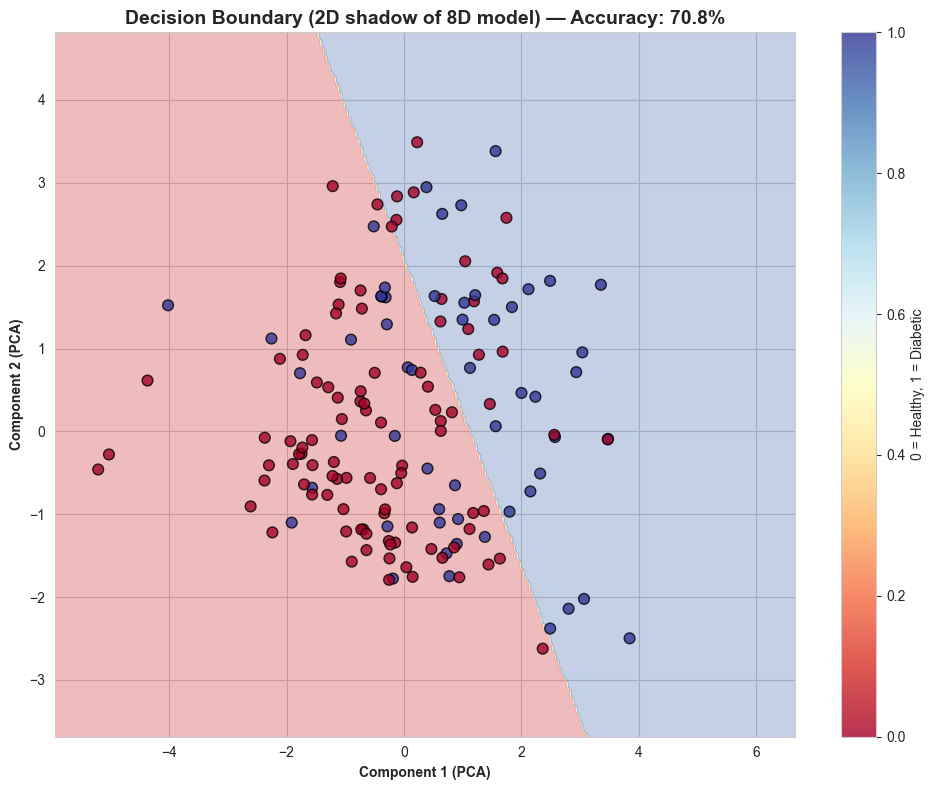

2D shadow accuracy:  70.8%  (some info lost in the projection)


In [27]:
from sklearn.decomposition import PCA

# Squash 8 dimensions → 2 dimensions (like casting a shadow)
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train_scaled)
X_test_2d  = pca.transform(X_test_scaled)

# Train a new model on the 2D version
model_2d = LogisticRegression(random_state=42, max_iter=1000)
model_2d.fit(X_train_2d, y_train)
acc_2d = model_2d.score(X_test_2d, y_test)

# Paint the decision regions
h = 0.05
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(10, 8))
ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
scatter = ax.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test,
                     cmap='RdYlBu', edgecolors='black', s=60, alpha=0.8)
ax.set_xlabel('Component 1 (PCA)', fontweight='bold')
ax.set_ylabel('Component 2 (PCA)', fontweight='bold')
ax.set_title(f'Decision Boundary (2D shadow of 8D model) — Accuracy: {acc_2d:.1%}',
             fontweight='bold', fontsize=14)
plt.colorbar(scatter, label='0 = Healthy, 1 = Diabetic')
plt.tight_layout()
plt.show()

print(f"2D shadow accuracy:  {acc_2d:.1%}  (some info lost in the projection)")
# print(f"Full 8D accuracy:    {acc:.1%}  (uses all features)")

> **Key takeaway:**  
> The decision boundary is a line (**in 2D**) or a surface (**in 8D**) that separates the two classes.
>
> Everything on one side → **"healthy"**  
> Everything on the other → **"diabetic"**

---

> But look closely at the dots near the boundary — the model is **uncertain** there.
>
> It's almost a coin flip.
>
> Which raises an important question:
>
> Does the model really just say **"yes"** or **"no"**?
>
> Or does it know **how confident** it is?

# The ROC Curve — Evaluating Across ALL Thresholds

---

```text
THE ONE NUMBER TO REMEMBER: AUC (Area Under Curve)

    AUC = 1.0  →  perfect
    AUC = 0.9  →  excellent
    AUC = 0.8  →  good   ← our diabetes model lands near here
    AUC = 0.7  →  okay
    AUC = 0.5  →  useless (coin flip)

Higher AUC = better model. No plot needed — just read the number.


THE CURVE BEHIND THE NUMBER:

     1.0 |
         | ┌──────────── Perfect model (AUC = 1.0)
         |/
TPR      |
(recall) |      /
  0.5 |  /              ← real model (AUC between 0.5 and 1.0)
      | /               AUC = the shaded area under this line
      |---------------- Coin flip (AUC = 0.5)
  0.0 |
      +------------------------------
        0.0    0.5    1.0

             FPR (false alarm rate)


Y-axis: sick people we CAUGHT (recall) — want HIGH
X-axis: healthy people we WRONGLY FLAGGED — want LOW

Top-left corner = dream.
Curve bows toward it → bigger AUC.
```

In [28]:
# predict_proba — the model's CONFIDENCE for each patient

y_proba_demo = model.predict_proba(X_test_scaled)

print("predict_proba gives TWO columns: P(Healthy) and P(Diabetic)")
print("=" * 60)

demo_df = pd.DataFrame({
    'P(Healthy)':  y_proba_demo[:8, 0].round(3),
    'P(Diabetic)': y_proba_demo[:8, 1].round(3),
    'Prediction':  ['Diabetic' if p > 0.5 else 'Healthy' for p in y_proba_demo[:8, 1]],
    'Actual':      ['Diabetic' if a == 1 else 'Healthy' for a in y_test.values[:8]]
})
display(demo_df)

print("\nDefault threshold = 0.5:")
print("  P(Diabetic) > 0.5 → predict Diabetic")
print("  P(Diabetic) ≤ 0.5 → predict Healthy")
print("\nWhat if we tried a DIFFERENT threshold?")

predict_proba gives TWO columns: P(Healthy) and P(Diabetic)


,P(Healthy),P(Diabetic),Prediction,Actual
0,0.723,0.277,Healthy,Healthy
1,0.814,0.186,Healthy,Healthy
2,0.885,0.115,Healthy,Healthy
3,0.829,0.171,Healthy,Healthy
4,0.532,0.468,Healthy,Healthy
5,0.560,0.440,Healthy,Healthy
6,0.984,0.016,Healthy,Healthy
7,0.340,0.660,Diabetic,Healthy



Default threshold = 0.5:
  P(Diabetic) > 0.5 → predict Diabetic
  P(Diabetic) ≤ 0.5 → predict Healthy

What if we tried a DIFFERENT threshold?


# Machine Learning Day 3: New Algorithms & Hyperparameter Tuning

## Week 5, Day 3 — More Tools, Smarter Models

---

### Today's Journey (~2.5 Hours)

| Part | Topic | Duration |
|------|--------|----------|
| **1** | Quick Review — Building a Titanic Baseline | ~10 min |
| **2** | K-Nearest Neighbors (KNN) | ~20 min |
| **3** | Support Vector Machines (SVM) | ~25 min |
| **BREAK 1** |  | **10 min** |
| **4** | Random Forest & Feature Importance | ~15 min |
| **5** | XGBoost — The Competition King | ~15 min |
| **6** | Hyperparameter Tuning with GridSearchCV | ~25 min |
| **BREAK 2** |  | **10 min** |
| **7** | Heart Disease Prediction (Exercises 1–7) | ~40 min |
| **8** | Daily Challenge — Breast Cancer Prediction | ~15 min |

---

### Learning Goals

By the end of today, you will be able to:

- Build and evaluate **K-Nearest Neighbors (KNN)** models
- Understand how **Support Vector Machines (SVM)** classify data
- Train and interpret **Random Forest** models
- Use **XGBoost** for high-performance classification
- Tune model parameters using **GridSearchCV**
- Compare multiple machine learning algorithms
- Apply advanced models to real-world healthcare datasets

---

### Key Takeaway

> Today is about moving beyond Logistic Regression and exploring powerful machine learning algorithms that can improve predictive performance through better model selection and hyperparameter tuning.

### TODAY'S PROMISE:

```text
┌─────────────────────────────────────────────────────────────────────┐
│                                                                     │
│  BEFORE (Days 1–2):                                                 │
│  One algorithm (Logistic Regression), manual parameter choices      │
│                                                                     │
│  AFTER (today):                                                     │
│  FIVE classification algorithms you can compare head-to-head:       │
│                                                                     │
│  LogReg | KNN | SVM | Random Forest | XGBoost                       │
│                                                                     │
│  PLUS: GridSearchCV — automatic hyperparameter tuning               │
│  (let the computer find the best settings for you)                  │
│                                                                     │
│  Same sklearn pattern. Same evaluate-and-compare workflow.          │
│  Now with the POWER OF CHOICE.                                      │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

In [30]:
# Setup — same libraries as Days 1 and 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("Ready for Day 3!")

Ready for Day 3!


---

# Part 1: Quick Review — Building Our Baseline

Let's build a complete ML pipeline on **Titanic** to establish a **baseline** for comparison.

Every new algorithm today will be measured against this.

In [31]:
# sklearn imports from Days 1 & 2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
)

print("All Day 1 & 2 imports loaded!")

All Day 1 & 2 imports loaded!


In [32]:
# Load Titanic — our familiar friend
titanic = sns.load_dataset('titanic')

# Prepare features (you know this drill!)
df = titanic[['survived', 'pclass', 'sex', 'age', 'fare']].dropna()
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

X = df[['pclass', 'sex', 'age', 'fare']]
y = df['survived']

print(f"Dataset: {len(df)} samples, {X.shape[1]} features")
print(f"Survival rate: {y.mean():.1%}")

Dataset: 714 samples, 4 features
Survival rate: 40.6%


In [33]:
# Split → Scale → Train → Evaluate (the complete pipeline)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)
y_pred_logreg = logreg.predict(X_test_scaled)

print("LOGISTIC REGRESSION BASELINE")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_logreg):.2%}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_logreg, target_names=['Died', 'Survived']))

LOGISTIC REGRESSION BASELINE
Accuracy: 79.02%

Classification Report:
              precision    recall  f1-score   support

        Died       0.82      0.84      0.83        85
    Survived       0.75      0.72      0.74        58

    accuracy                           0.79       143
   macro avg       0.78      0.78      0.78       143
weighted avg       0.79      0.79      0.79       143



> ## Baseline Established!
>
> **Logistic Regression:** ~80% accuracy on Titanic
>
> **The question for today:** Can we do better with other algorithms?

---

# Part 2: K-Nearest Neighbors (KNN)

## The Idea: Look at Your Neighbors

**Logistic Regression** draws a straight line to separate classes. But what if the boundary is **NOT** a straight line?

```text
Logistic Regression works here:      But NOT here:

  o o o o | ● ● ● ●                o o ● o o
  o o o   | ● ● ● ●                o ● ● ● o
  o o     |   ● ● ●                ● ● o ● ●

 ← Died | Survived →              (boundaries are curved!)
```

### KNN Algorithm:

1. Given a new data point, find the **K closest training points**
2. Take a **vote** — whatever the majority of neighbors are, that's the prediction
3. Done!

It's like asking your **5 nearest neighbours** whether the local restaurant is good.

---

## "But how do I know if the boundary is linear?"

**Short answer:** you usually don't know in advance — and that's OK!

In practice, you try multiple models and compare results:

- If **Logistic Regression (linear)** does just as well as **KNN/SVM** → the boundary is probably linear
- If **KNN or SVM (non-linear)** do noticeably better → the boundary is probably curved

That's exactly what we'll do today: train **multiple algorithms** on the same data and let the results tell us.

> **Rule of thumb:** With real data, start simple (**Logistic Regression**). If it works well, stop there. If not, try non-linear models.

### How Distance is Calculated

KNN needs to measure **"closeness."** The default is **Euclidean distance** (straight-line distance):

$$
d = \sqrt{(x_1 - x_2)^2 + (y_1 - y_2)^2 + \dots}
$$

### This is why scaling matters for KNN!

- **Fare (0–500)** would dominate **Age (0–80)** without scaling
- After **StandardScaler**, all features are on the same scale

In [34]:
# Import KNN
from sklearn.neighbors import KNeighborsClassifier

# Train KNN with K=5 (default, good starting point)
# WHY K=5? Odd number avoids ties, 5 is a common default
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)  # MUST use scaled data for KNN!

y_pred_knn = knn.predict(X_test_scaled)

print("K-Nearest Neighbors (K=5):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.2%}")
print(f"\nvs Logistic Regression: {accuracy_score(y_test, y_pred_logreg):.2%}")

K-Nearest Neighbors (K=5):
Accuracy: 77.62%

vs Logistic Regression: 79.02%


KNN Classification Report:
              precision    recall  f1-score   support

        Died       0.80      0.82      0.81        85
    Survived       0.73      0.71      0.72        58

    accuracy                           0.78       143
   macro avg       0.77      0.77      0.77       143
weighted avg       0.78      0.78      0.78       143



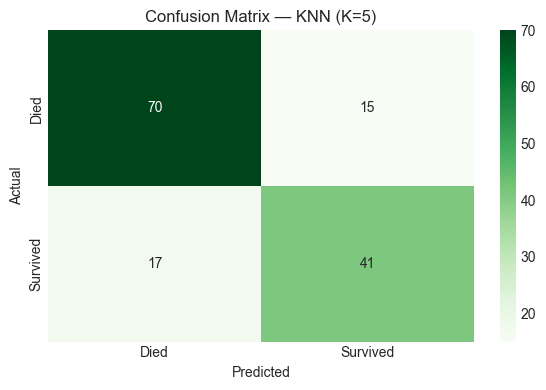

In [35]:
# Full evaluation for KNN
print("KNN Classification Report:")
print(classification_report(y_test, y_pred_knn, target_names=['Died', 'Survived']))

# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — KNN (K=5)')
plt.tight_layout()
plt.show()

# Overfitting vs Underfitting

**Overfitting** = the model memorises training data but fails on new data.  
**Underfitting** = the model is too simple to capture patterns.

```text
┌─────────────────────────┬─────────────────────────┬─────────────────────────┐
│ OVERFITTING (K=1):      │ SWEET SPOT (K=5–9):    │ UNDERFITTING (K=100):  │
│                         │                         │                         │
│ Training:  99%          │ Training:  85%         │ Training:  70%         │
│ Test:      72%          │ Test:      82%         │ Test:      68%         │
│ Gap:       27% ← BAD    │ Gap:       3% ← GOOD   │ Gap:       2% ← Low!   │
│                         │                         │                         │
│ Memorised!              │ Generalised!           │ Too simple!            │
└─────────────────────────┴─────────────────────────┴─────────────────────────┘
```

## With KNN, K controls the trade-off:

- **Low K (1–3):** Complex boundary → overfits
- **High K (50+):** Too smooth → underfits
- **Sweet spot:** Usually **K = 5** to **K = 15**

In [36]:
# Experiment with different K values
k_values = [1, 3, 5, 7, 9, 15, 25, 50]
train_accuracies = []
test_accuracies = []

print("Effect of K on KNN Performance:")
print("=" * 50)
print(f"{'K':>5} | {'Train Acc':>10} | {'Test Acc':>10} | Notes")
print("-" * 50)

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)

    train_acc = accuracy_score(y_train, knn_temp.predict(X_train_scaled))
    test_acc  = accuracy_score(y_test,  knn_temp.predict(X_test_scaled))
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    note = ""
    if k == 1:
        note = "← Overfitting (memorised!)"
    elif k == 50:
        note = "← Underfitting (too smooth)"
    elif test_acc == max(test_accuracies):
        note = "← Best so far!"

    print(f"{k:>5} | {train_acc:>10.2%} | {test_acc:>10.2%} | {note}")

Effect of K on KNN Performance:
    K |  Train Acc |   Test Acc | Notes
--------------------------------------------------
    1 |     98.77% |     72.73% | ← Overfitting (memorised!)
    3 |     90.02% |     78.32% | ← Best so far!
    5 |     86.34% |     77.62% | 
    7 |     83.71% |     79.02% | ← Best so far!
    9 |     83.54% |     79.72% | ← Best so far!
   15 |     81.96% |     81.82% | ← Best so far!
   25 |     81.26% |     79.02% | 
   50 |     77.58% |     79.02% | ← Underfitting (too smooth)


# Visualising KNN Decision Boundaries

Let's **SEE** how KNN makes decisions. We'll use just **2 features** so we can plot in **2D**.

In [37]:
# Create a 2D dataset for visualisation
X_2d = df[['age', 'fare']].values
y_2d = df['survived'].values

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y_2d, test_size=0.2, random_state=42
)

scaler_2d = StandardScaler()
X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled  = scaler_2d.transform(X_test_2d)

# Decision boundary plotting function (we'll reuse this for ALL models)
def plot_decision_boundary(model, X, y, title, ax):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', edgecolors='black', s=20)
    ax.set_title(title)
    ax.set_xlabel('Age (scaled)')
    ax.set_ylabel('Fare (scaled)')

print("2D data prepared & plot function defined!")

2D data prepared & plot function defined!


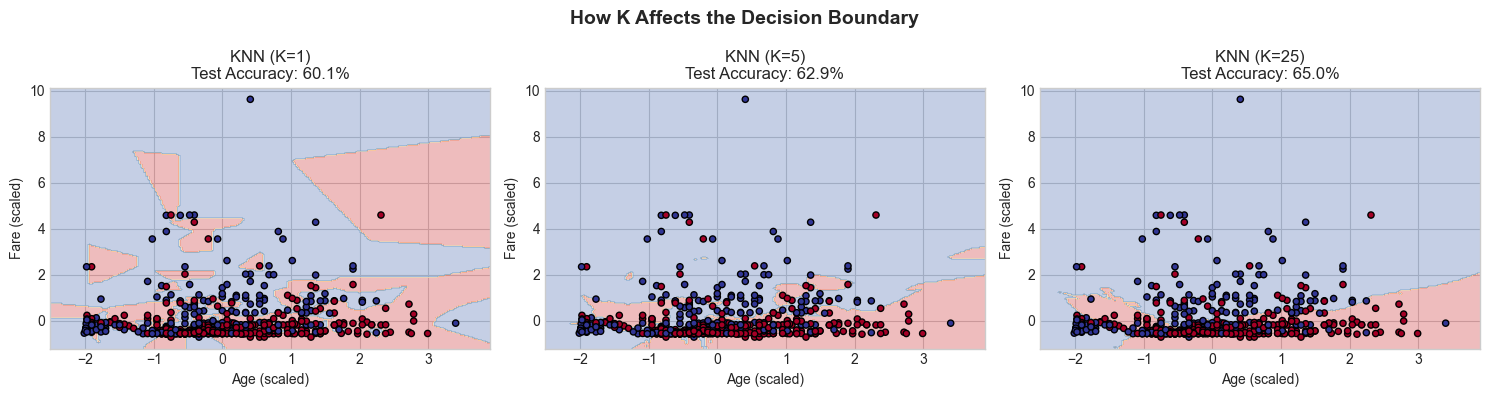

In [38]:
# Compare KNN decision boundaries with different K values
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, k in zip(axes, [1, 5, 25]):
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_2d_scaled, y_train_2d)
    acc = accuracy_score(y_test_2d, knn_temp.predict(X_test_2d_scaled))
    plot_decision_boundary(knn_temp, X_train_2d_scaled, y_train_2d,
                           f'KNN (K={k})\nTest Accuracy: {acc:.1%}', ax)

plt.suptitle('How K Affects the Decision Boundary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Key Hyperparameters for KNN

| Parameter | What it means | How to choose |
|-----------|--------------|---------------|
| `n_neighbors` | How many neighbors to consider (K) | Start with **5**, use odd numbers |
| `weights` | How to weight neighbor votes | `'uniform'` (all equal) or `'distance'` (closer = more weight) |
| `metric` | How to measure distance | `'euclidean'` (default), `'manhattan'` |

## When to Use KNN

| Good for | Bad for |
|-----------|----------|
| Small to medium datasets (< 10k) | Large datasets (slow!) |
| When decision boundary is non-linear | High-dimensional data |
| Quick baseline | When you need interpretability |

---

---

# Part 3: Support Vector Machines (SVM)

KNN is intuitive, but it has a weakness: it stores **ALL** training data and compares every new point to every stored point. For large datasets, that's **slow**. And it doesn't give us a clear **boundary** we can inspect.

SVM takes a completely different approach.

## The Problem: Finding the BEST Boundary

Many lines can separate the data. Which one is **best**?

```text
THREE possible boundaries — all separate the classes correctly:

   o o o | ● ● ●        o o o| ● ● ●        o o o  |● ● ●
   o o   |   ● ●        o o  |   ● ●        o o    |  ● ●
   o     |     ●        o    |     ●        o      |    ●
```

**SVM's answer:** The line with the **MAXIMUM MARGIN** — the widest gap between the boundary and the nearest data points on each side.

```text
   o o o      ||      ● ● ●
   o o    <-->||<-->  ● ●
   o          ||      ●

          support
          vectors          ← MAXIMUM MARGIN
```

The nearest points to the boundary are called **support vectors** — they "support" the boundary.

In [39]:
# Import SVM
from sklearn.svm import SVC  # SVC = Support Vector Classifier

# Train SVM with default settings (RBF kernel)
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train_scaled, y_train)  # MUST use scaled data!

y_pred_svm = svm.predict(X_test_scaled)

print("Support Vector Machine (RBF kernel):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.2%}")
print(f"\nvs Logistic Regression: {accuracy_score(y_test, y_pred_logreg):.2%}")
print(f"vs KNN (K=5):           {accuracy_score(y_test, y_pred_knn):.2%}")

Support Vector Machine (RBF kernel):
Accuracy: 80.42%

vs Logistic Regression: 79.02%
vs KNN (K=5):           77.62%


In [40]:
# Compare different kernels
print("Comparing SVM Kernels:")
print("=" * 50)

kernels = ['linear', 'rbf', 'poly']
for kernel in kernels:
    svm_temp = SVC(kernel=kernel, random_state=42)
    svm_temp.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, svm_temp.predict(X_test_scaled))
    print(f"  {kernel:8s}: {acc:.2%}")

Comparing SVM Kernels:
  linear  : 78.32%
  rbf     : 80.42%
  poly    : 79.02%


## The C Parameter: How Much Do We Punish Mistakes?

**C** controls the trade-off between a **wide margin** and **correct classifications**:

- **Low C (0.01):** *"I'm okay with some mistakes if it means a wider margin"* → simpler model
- **High C (100):** *"Classify EVERY training point correctly!"* → complex, risk of overfitting

```text
LOW C = Wide margin, some errors        HIGH C = Narrow margin, fewer errors

      o o o       |                           o o o \       / o o o
      o o         |                           o o     \   /     o o
            ●     |                                 ●   \ / 
                  |                                       V

     misclassified but OK                  gets it right but tight
```

### Rule of Thumb

| C Value | Effect |
|----------|---------|
| Small C | Wider margin, more tolerance for errors, simpler model |
| Medium C | Good balance between margin and accuracy |
| Large C | Fewer training errors, narrower margin, higher risk of overfitting |

> **Remember:**  
> **Low C = Simpler model, wider margin**  
> **High C = More complex model, tighter fit**

In [41]:
# Effect of C on SVM
print("Effect of C on SVM (RBF kernel):")
print("=" * 60)
print(f"{'C':>8} | {'Train Acc':>10} | {'Test Acc':>10} | Notes")
print("-" * 60)

c_values = [0.001, 0.01, 0.1, 1, 10, 100]
for c in c_values:
    svm_temp = SVC(C=c, kernel='rbf', random_state=42)
    svm_temp.fit(X_train_scaled, y_train)

    train_acc = accuracy_score(y_train, svm_temp.predict(X_train_scaled))
    test_acc  = accuracy_score(y_test,  svm_temp.predict(X_test_scaled))

    note = ""
    if c <= 0.01:
        note = "← Underfitting (too simple)"
    elif c >= 100:
        note = "← Risk of overfitting"

    print(f"{c:>8} | {train_acc:>10.2%} | {test_acc:>10.2%} | {note}")

Effect of C on SVM (RBF kernel):
       C |  Train Acc |   Test Acc | Notes
------------------------------------------------------------
   0.001 |     59.37% |     59.44% | ← Underfitting (too simple)
    0.01 |     59.37% |     59.44% | ← Underfitting (too simple)
     0.1 |     77.76% |     78.32% | 
       1 |     82.14% |     80.42% | 
      10 |     83.89% |     83.92% | 
     100 |     84.59% |     80.42% | ← Risk of overfitting


# Key Hyperparameters for SVM

| Parameter | What it means | How to choose |
|-----------|---------------|---------------|
| `C` | Regularisation (penalty for errors) | 0.1–100, higher = more complex |
| `kernel` | Type of boundary | `'rbf'` for most cases |
| `gamma` | How "local" vs "global" the model is | `'scale'` (default) is usually good |

## When to Use SVM

| Good for | Bad for |
|-----------|----------|
| Medium datasets (100s–10,000s) | Very large datasets (slow) |
| High-dimensional data (text, images) | When you need probability outputs |
| Clear margin of separation | When interpretability matters |

---

# Comparing All Models — Decision Boundaries Side by Side

Let's see how **LogReg**, **KNN**, and **SVM** draw boundaries on the **SAME** data:

---

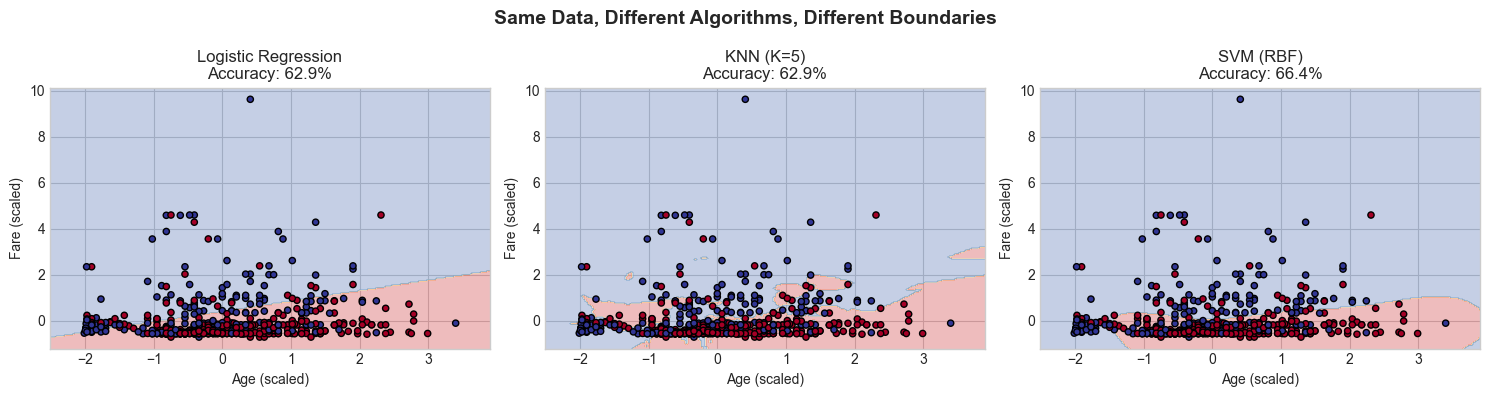

In [42]:
# Compare ALL models so far — same 2D data, different boundaries
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Logistic Regression
logreg_2d = LogisticRegression(max_iter=1000)
logreg_2d.fit(X_train_2d_scaled, y_train_2d)
acc = accuracy_score(y_test_2d, logreg_2d.predict(X_test_2d_scaled))
plot_decision_boundary(logreg_2d, X_train_2d_scaled, y_train_2d,
                       f'Logistic Regression\nAccuracy: {acc:.1%}', axes[0])

# KNN
knn_2d = KNeighborsClassifier(n_neighbors=5)
knn_2d.fit(X_train_2d_scaled, y_train_2d)
acc = accuracy_score(y_test_2d, knn_2d.predict(X_test_2d_scaled))
plot_decision_boundary(knn_2d, X_train_2d_scaled, y_train_2d,
                       f'KNN (K=5)\nAccuracy: {acc:.1%}', axes[1])

# SVM
svm_2d = SVC(kernel='rbf', random_state=42)
svm_2d.fit(X_train_2d_scaled, y_train_2d)
acc = accuracy_score(y_test_2d, svm_2d.predict(X_test_2d_scaled))
plot_decision_boundary(svm_2d, X_train_2d_scaled, y_train_2d,
                       f'SVM (RBF)\nAccuracy: {acc:.1%}', axes[2])

plt.suptitle('Same Data, Different Algorithms, Different Boundaries',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

# Part 4: Random Forest & Feature Importance

So far we have models that draw boundaries (**LogReg, SVM**) and one that looks at neighbours (**KNN**). Now for something fundamentally different: **tree-based models**.

## Wisdom of the Crowd: Many Trees Beat One Tree

Remember Decision Trees from Day 1? A single tree asks yes/no questions to split the data. Simple and interpretable — but **fragile**. Small changes in data → completely different tree.

**Solution:** Build many trees and let them vote!

```text
New passenger: [Female, 1st class, age 25, fare $100]


Tree 1:  Survived  ✓
Tree 2:  Survived  ✓
Tree 3:  Died      ✗
Tree 4:  Survived  ✓
Tree 5:  Survived  ✓
                     VOTE → Survived (3 vs 1)

...
Tree 100: Survived ✓


Final Prediction: SURVIVED (majority vote)
```

### Key Insight

**Random Forest does NOT need scaled data**  
(it's tree-based, uses thresholds not distances).

---

## How Random Forest Actually Works — Step by Step

Let's see the **"wisdom of the crowd"** in action. We'll build individual trees and watch them disagree, then agree.

In [43]:
# Import and train Random Forest
from sklearn.ensemble import RandomForestClassifier

# IMPORTANT: Random Forest does NOT need scaled data!
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)  # Using X_train, NOT X_train_scaled!

y_pred_rf = rf.predict(X_test)

print("Random Forest (100 trees):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.2%}")
print(f"\nComparison so far:")
print(f"  Logistic Regression: {accuracy_score(y_test, y_pred_logreg):.2%}")
print(f"  KNN (K=5):           {accuracy_score(y_test, y_pred_knn):.2%}")
print(f"  SVM (RBF):           {accuracy_score(y_test, y_pred_svm):.2%}")
print(f"  Random Forest:       {accuracy_score(y_test, y_pred_rf):.2%}")

Random Forest (100 trees):
Accuracy: 79.72%

Comparison so far:
  Logistic Regression: 79.02%
  KNN (K=5):           77.62%
  SVM (RBF):           80.42%
  Random Forest:       79.72%


## Feature Importance: Which Features Matter Most?

One of the **BEST features of Random Forest** — it tells you **which features are most important!**

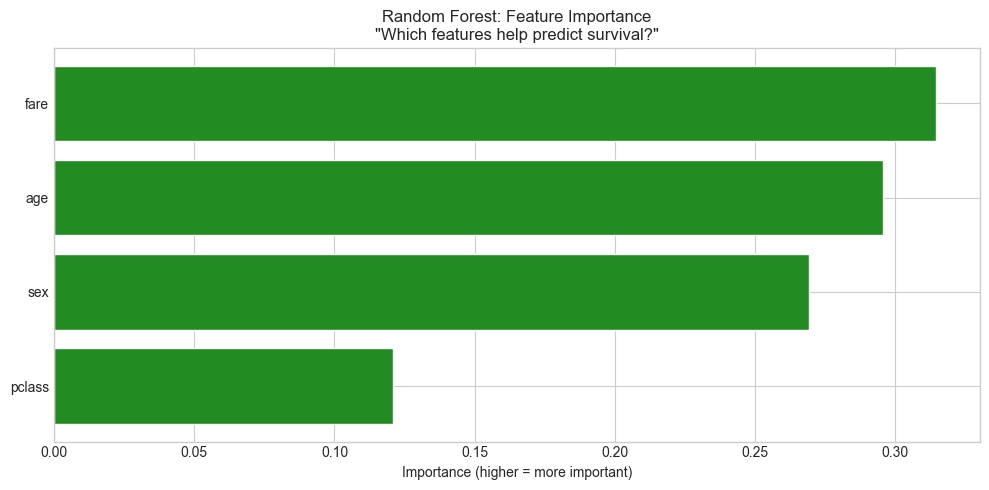


Feature Importance Rankings:
  fare    : 0.314 ███████████████
  age     : 0.295 ██████████████
  sex     : 0.269 █████████████
  pclass  : 0.121 ██████


In [44]:
# Feature importance
importances = rf.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='forestgreen')
plt.xlabel('Importance (higher = more important)')
plt.title('Random Forest: Feature Importance\n"Which features help predict survival?"')
plt.tight_layout()
plt.show()

print("\nFeature Importance Rankings:")
for _, row in importance_df.sort_values('Importance', ascending=False).iterrows():
    bar = "█" * int(row['Importance'] * 50)
    print(f"  {row['Feature']:8s}: {row['Importance']:.3f} {bar}")